In [27]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)  # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

Running on: cpu


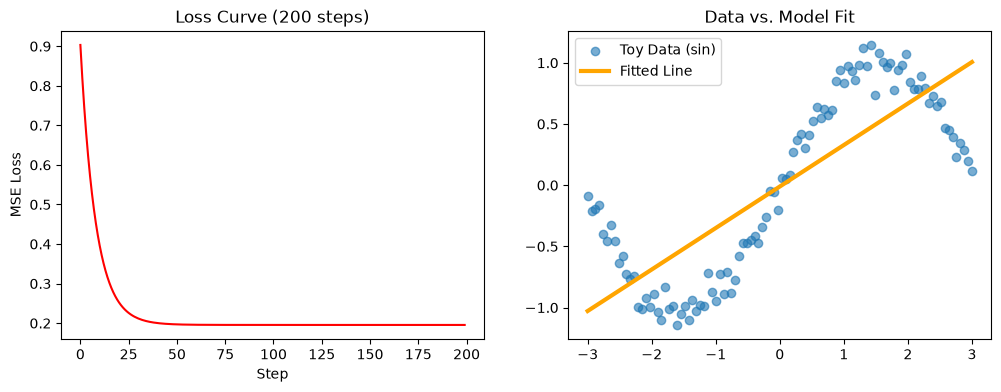

In [28]:
## Part 1.1

# 1. Generate the toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

# 2. Initialise w and b to small random values
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1
lr = 0.01
losses = []

# 3. Implement ONE gradient-descent step by hand, looped
for i in range(200):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    w -= lr * dw
    b -= lr * db

# 4. Plot the loss curve and the fitted line
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(losses, color="red")
ax1.set_title("Loss Curve (200 steps)")
ax1.set_xlabel("Step")
ax1.set_ylabel("MSE Loss")

ax2.scatter(x, y, label="Toy Data (sin)", alpha=0.6)
ax2.plot(x, w * x + b, color="orange", linewidth=3, label="Fitted Line")
ax2.set_title("Data vs. Model Fit")
ax2.legend()

plt.show()

![LossFuncDerivative](LossFunction_Derivative.png)


2. There is severe underfitting. A single neuron with no activation function calculates a purely linear combination. Mathematically, a straight line can never capture the periodic, non-linear carvature of a sine wave, regardless of how many epochs you train it for.


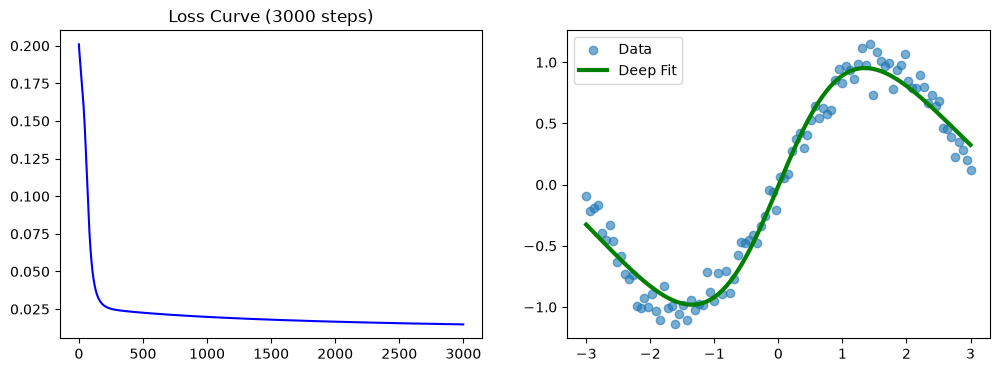

In [29]:
##Part 1.2
# # 1. Initialise parameters
W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros((8,))
W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros((1,))

# Reshape data for matrix multiplication
x_mat = x.reshape(-1, 1)
y_mat = y.reshape(-1, 1)
lr = 0.05
losses = []

# 2 & 3. Forward pass, Backward pass, and Updates
for i in range(3000):
    # Forward Pass
    z1 = x_mat @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2

    loss = np.mean((y_hat - y_mat) ** 2)
    losses.append(loss)

    # Backward Pass
    d_yhat = 2 * (y_hat - y_mat) / len(y_mat)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x_mat.T @ dz1
    db1 = dz1.sum(axis=0)

    # Update parameters
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

# 4. Plot the loss curve and the final fit
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(losses, color="blue")
ax1.set_title("Loss Curve (3000 steps)")

ax2.scatter(x, y, label="Data", alpha=0.6)
ax2.plot(x, y_hat, color="green", linewidth=3, label="Deep Fit")
ax2.legend()
plt.show()

1.Why Linear layers collapse:
if you remove the tanh activatio, the forward pass becomes ^y = (xw1 + b1)w2 +b2. by expanding this, it becomes : ^y = x(w1w2) +(b1w2+b2). Let W(new) = w1w2 and b(new) = b1w2 + b2. The equation simplifies perfectly to ^y = xw(new) + b(new), which is just a single linear tranformation.

2.The role of the 8 hidden neurons:
Each of the 8 neurons learns to represent a different bounded tanh "s-curve" located at different segments along the x-axis. The final output layer linearly combines these 8 separate curves to approximate the complex, non-linear shape of the sine wave

3. What is backpropagation?
   Backpropagation is an algorithm that uses the calculus chain rule to efficiently calculate the gradient of the loss function with respect to every single weight and bias in the neural network, moving backward from the output layer to the input layer.


c:\Users\Prince\Desktop\Sup_Unsup_Learning\.venv\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\Prince\AppData\Local\Temp\ipykernel_1772\4084647408.py:17: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y_mat) ** 2)
C:\Users\Prince\AppData\Local\Temp\ipykernel_1772\4084647408.py:24: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
C:\Users\Prince\AppData\Local\Temp\ipykernel_1772\4084647408.py:25: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
c:\Users\Prince\Desktop\Sup_Unsup_Learning\.venv\Lib\site-packages\matplotlib\scale.py:375: RuntimeWarning: overflow encountered in exp
  return np.exp(values * np.log(self.base))


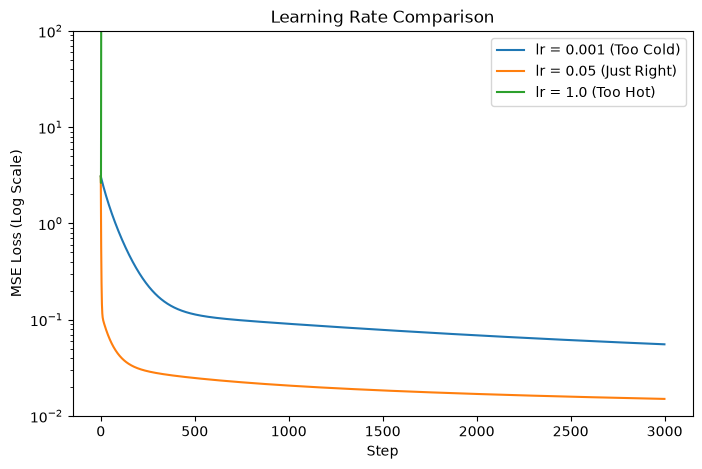

In [30]:
## Part 1.3


def train_toy(lr, steps=3000):
    np.random.seed(42)  # Ensure fair comparison
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros((8,))
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros((1,))

    losses = []  ## Set to record losses
    for _ in range(steps):
        # Forward
        z1 = x_mat @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss = np.mean((y_hat - y_mat) ** 2)
        losses.append(loss)

        # Backward
        d_yhat = 2 * (y_hat - y_mat) / len(y_mat)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = x_mat.T @ dz1
        db1 = dz1.sum(axis=0)

        # Update
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return losses


losses_slow = train_toy(0.001)
losses_good = train_toy(0.05)
losses_fast = train_toy(1.0)

plt.figure(figsize=(8, 5))
plt.plot(losses_slow, label="lr = 0.001 (Too Cold)")
plt.plot(losses_good, label="lr = 0.05 (Just Right)")
plt.plot(losses_fast, label="lr = 1.0 (Too Hot)")
plt.yscale("log")
plt.ylabel("MSE Loss (Log Scale)")
plt.xlabel("Step")
plt.title("Learning Rate Comparison")
plt.ylim(1e-2, 100)
plt.legend()
plt.show()

c:\Users\Prince\Desktop\Sup_Unsup_Learning\.venv\Lib\site-packages\numpy_core_methods.py:132: RuntimeWarning: overflow encountered in reduce
ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\Prince\AppData\Local\Temp\ipykernel_1772\443768776.py:16: RuntimeWarning: overflow encountered in square
loss = np.mean((y_hat - y_mat) ** 2)
C:\Users\Prince\AppData\Local\Temp\ipykernel_1772\443768776.py:23: RuntimeWarning: overflow encountered in matmul
dh = d_yhat @ W2.T
C:\Users\Prince\AppData\Local\Temp\ipykernel_1772\443768776.py:24: RuntimeWarning: invalid value encountered in multiply
dz1 = dh \* (1 - np.tanh(z1) ** 2)
c:\Users\Prince\Desktop\Sup_Unsup_Learning\.venv\Lib\site-packages\matplotlib\scale.py:375: RuntimeWarning: overflow encountered in exp
return np.exp(values \* np.log(self.base))

Student Reasoning - Learning Rate:
0.001 is Too cold: The Loss drops very slowly. The steps taken down the gradient are so tiny that the models fails to converge within the 3000 epochs

0.05 is Just Right: The loss drops rapidly and smooths out, finding the local minimum efficiently without overshooting.
0.1 is considered too hot: Thge curve oscillates widely or explodes. The step sizes are so large that the optimizer continuously overshoots the minimum of the loss valley, bouncing back and forth up the sides instead of settling at the bottom.


In [31]:
##Part 2.1 Preprocess and Split



obesity = pd.read_csv(OBESITY_URL)

## Cleaning Data:
print("\nMissing Values:")
print(obesity.isnull().sum())

# Make a copy of the dataset
obesity_processed = obesity.copy()

# 1. Encode binary Yes/No columns

binary_map = {"yes": 1, "no": 0, "Yes": 1, "No": 0}

binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]

for col in binary_cols:
    obesity_processed[col] = obesity_processed[col].map(binary_map)

# -----------------------------
# 2. Encode ordinal columns
# -----------------------------
ordinal_encoder = OrdinalEncoder(
    categories=[
        ["no", "Sometimes", "Frequently", "Always"],  # CAEC
        ["no", "Sometimes", "Frequently", "Always"],  # CALC
    ]
)

obesity_processed[["CAEC", "CALC"]] = ordinal_encoder.fit_transform(
    obesity_processed[["CAEC", "CALC"]]
)


# 3. One-Hot Encode nominal columns

obesity_processed = pd.get_dummies(
    obesity_processed, columns=["Gender", "MTRANS"], drop_first=True
)


# 5. Encode the target

label_encoder = LabelEncoder()

obesity_processed["NObeyesdad"] = label_encoder.fit_transform(
    obesity_processed["NObeyesdad"]
)


# 6. Separate Features and Target

X = obesity_processed.drop("NObeyesdad", axis=1)
y = obesity_processed["NObeyesdad"]


# Split (60 / 20 / 20)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42) 
# Note: 0.25 of 0.8 is 0.2 (giving 60/20/20)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to Tensors (ensure numpy arrays / 1D label arrays)
X_train_t = torch.tensor(np.asarray(X_train), dtype=torch.float32)
y_train_t = torch.tensor(np.asarray(y_train).astype(np.int64), dtype=torch.long)
X_val_t = torch.tensor(np.asarray(X_val), dtype=torch.float32)
y_val_t = torch.tensor(np.asarray(y_val).astype(np.int64), dtype=torch.long)
X_test_t = torch.tensor(np.asarray(X_test), dtype=torch.float32)
y_test_t = torch.tensor(np.asarray(y_test).astype(np.int64), dtype=torch.long)

# DataLoaders
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)

INPUT_DIM = X_train_t.shape[1]


Missing Values:
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64


Student Reasoning:

1. Why Integer class Labels:Pytorch's nn.CrossEntropyLoss is highly optimized. Instead of taking one-hot vectors and redundant matrix multiplications, it takes the raw logits and 1 dimensional integer array, applying LogSoftmax and NLLLoss under the hood. It uses the integer as a direct index to fetch the probability of the correct class saving memory and compute
2. Why scaling Matters: In section one, we saw the gradient for the wights multiplied by the input x(change(Loss)/change(w) multiplied by x). If features have highly varying scales for instance if Age is 10 and weight is 100s, their gradients will be skewed, making the loss landscape highly elongated. This forces the optimizer to take inefficient Zig-zag steps and require tiny learning rates to avoid exploding gradients. 


3. shuffle=True: Shuffling randomizes the order of data in every epoch. This prevents the network from memorizing the sequence of the dataset or encountering correlated batches (like 32 "Normal Weight" samples in a row), which would bias the gradient updates and lead to unstable learning.

In [32]:
##Part 2.2

class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super(FeedForwardNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_sizes[0])
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.fc3 = nn.Linear(hidden_sizes[1], n_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)  # Raw logits out
        return x

model = FeedForwardNet(input_dim=INPUT_DIM).to(DEVICE)
print(model)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {num_params}")

FeedForwardNet(
  (fc1): Linear(in_features=19, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=7, bias=True)
  (relu): ReLU()
)
Total Trainable Parameters: 3591


1. Parameter Count Breakdown
Layer 1(fc1) =  19*64 +64  = 1280
 Layer 2(fc2) = 64*32 +32 = 2080
  Layer 3(fc3) = 32*7 +7 = 231
Total Trainable Parameters = 1280 + 2080 +231 = 3591


2. The ReLu(max(0, x)) solves the vanihing gradient problem for positive values. its derivates is exactly 1 for inputs  > 0, preventing gradients from shrinking to zero in deep networks unlike tanh which squashes gradients flat at the extremes. This is also computationally cheaper to calculate

3. Without ReLUs: If we removed the ReLUs, the entire network will mathematically collapse  down to a single linear transformation, which means it could only separate classes using flat hyperplanes, totally failing to learn complex, non-linear relationships.


Epoch 01 | Train Loss: 1.8935 Acc: 0.2401 | Val Loss: 1.8158 Acc: 0.3744
Epoch 02 | Train Loss: 1.7032 Acc: 0.4605 | Val Loss: 1.5569 Acc: 0.5758
Epoch 03 | Train Loss: 1.3665 Acc: 0.5877 | Val Loss: 1.1811 Acc: 0.6232
Epoch 04 | Train Loss: 1.0460 Acc: 0.6485 | Val Loss: 0.9366 Acc: 0.6825
Epoch 05 | Train Loss: 0.8457 Acc: 0.7196 | Val Loss: 0.7954 Acc: 0.7346
Epoch 06 | Train Loss: 0.7120 Acc: 0.7622 | Val Loss: 0.7022 Acc: 0.7299
Epoch 07 | Train Loss: 0.6178 Acc: 0.7899 | Val Loss: 0.6259 Acc: 0.8033
Epoch 08 | Train Loss: 0.5358 Acc: 0.8278 | Val Loss: 0.5646 Acc: 0.8318
Epoch 09 | Train Loss: 0.4678 Acc: 0.8547 | Val Loss: 0.5168 Acc: 0.8246
Epoch 10 | Train Loss: 0.4126 Acc: 0.8760 | Val Loss: 0.4718 Acc: 0.8555
Epoch 11 | Train Loss: 0.3698 Acc: 0.8847 | Val Loss: 0.4401 Acc: 0.8460
Epoch 12 | Train Loss: 0.3268 Acc: 0.9021 | Val Loss: 0.4125 Acc: 0.8555
Epoch 13 | Train Loss: 0.2939 Acc: 0.9179 | Val Loss: 0.3824 Acc: 0.8863
Epoch 14 | Train Loss: 0.2655 Acc: 0.9242 | Val Los

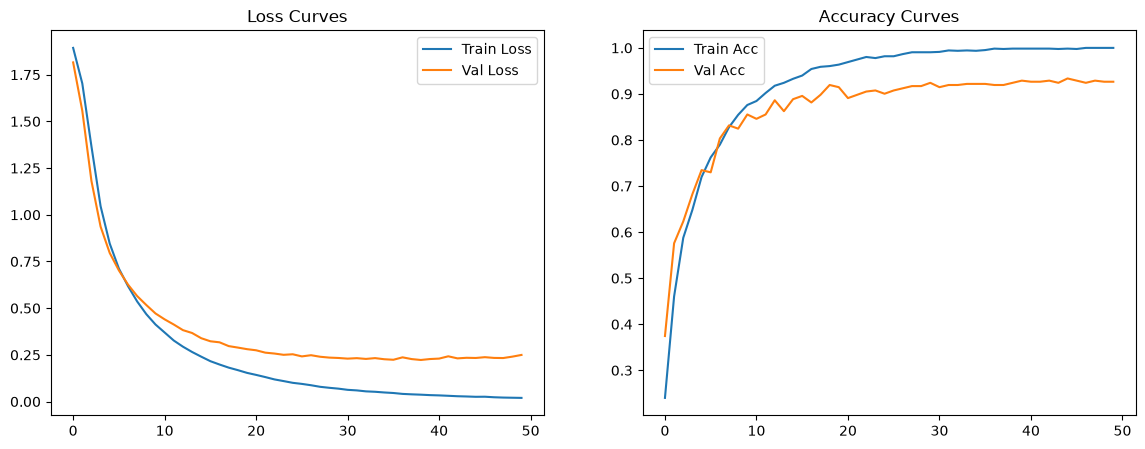

In [33]:

## Part 2.3
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 50
train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_val_acc = 0.0

for epoch in range(epochs):
    # 1. Training Phase
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * xb.size(0)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
        
    train_losses.append(running_loss / total)
    train_accs.append(correct / total)
    
    # 2. Validation Phase
    model.eval()
    val_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            
            val_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            v_correct += (preds == yb).sum().item()
            v_total += yb.size(0)
            
    val_losses.append(val_loss / v_total)
    val_accs.append(v_correct / v_total)
    
    if val_accs[-1] > best_val_acc:
        best_val_acc = val_accs[-1]
        torch.save(model.state_dict(), "ffn_best.pt")
        
    print(f"Epoch {epoch+1:02d} | Train Loss: {train_losses[-1]:.4f} Acc: {train_accs[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} Acc: {val_accs[-1]:.4f}")

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_title("Loss Curves")
ax1.legend()

ax2.plot(train_accs, label='Train Acc')
ax2.plot(val_accs, label='Val Acc')
ax2.set_title("Accuracy Curves")
ax2.legend()
plt.show()


Student Reasoning 
1. Mapping code to Numpy:
Logits = model(xb) goes with the forward pass logic(bidirectional)
loss.backward() maps unto the chain rulederivatives (bidirectional)
optimizer.step() maps unto the parameters

2. Model Fit Analysis: Typically, if train accuracy hits 98% and validation at 85%, the model is slightyly overfitting. The validation loss curve begin to curve upwards in later epochs while loss continues roward zero.

3. optimizer.zero_grad() : Pytorch accumulates  gradients across backward passes. If they are not zeroed out at the start of the batch, the gradient from batch 1 will be added to the gradients from batch 2, resulting in the optimizer updating parametrs in completely the wrong direction.
